#  LangGraph End-to-End: Senior Engineer Guide

> **Coverage:** State Machines → StateGraph → Nodes → Edges → Conditional Routing → Cycles → Checkpointing → HITL → Multi-Agent

---

## What is LangGraph?

LangGraph is a library for building **stateful, multi-step LLM applications** as directed graphs. It extends LangChain to support:
- **Cycles** (loops, not just linear pipelines)
- **Persistent state** across steps
- **Human-in-the-loop** interrupts
- **Multi-agent coordination**

```
LangChain (linear):    Input → Prompt → LLM → Output

LangGraph (graph):     
   __START__
       |
    [agent]  <───────────────────────────.
       |                                  |
   [conditional_edge]                     |
     /         \                          |
 [tools]   [__END__]  ───────────────┘
    |               (loop back)
 [observe]         
    |
 ────>
```

## Graph Theory Foundation

LangGraph is a **Directed Graph** $G = (V, E)$:
- $V$ = set of nodes (processing steps)
- $E \subseteq V \times V$ = directed edges

**State** flows through edges as messages:

$$\text{state}_{t+1} = \text{node}(\text{state}_t)$$

**Adjacency Matrix** for a graph with $n$ nodes:

$$A[i][j] = \begin{cases} 1 & \text{if edge } i \to j \text{ exists} \\ 0 & \text{otherwise} \end{cases}$$

**Topological Sort** (for DAGs, no cycles) runs in $O(V + E)$.

For graphs **with cycles** (LangGraph agents), we need a **termination condition** (else infinite loop):

$$\text{terminate when: } \text{steps} \geq \text{max\_steps} \;\text{ OR }\; \text{tool\_calls} = \emptyset$$

### State Reducer Pattern

Each field in state can have a **reducer** function:

$$\text{new\_state}[k] = \text{reducer}_k(\text{old\_state}[k], \text{update}[k])$$

Example: `messages` field uses `append` reducer:

$$\text{messages}_{t+1} = \text{messages}_t + [\text{new\_message}]$$

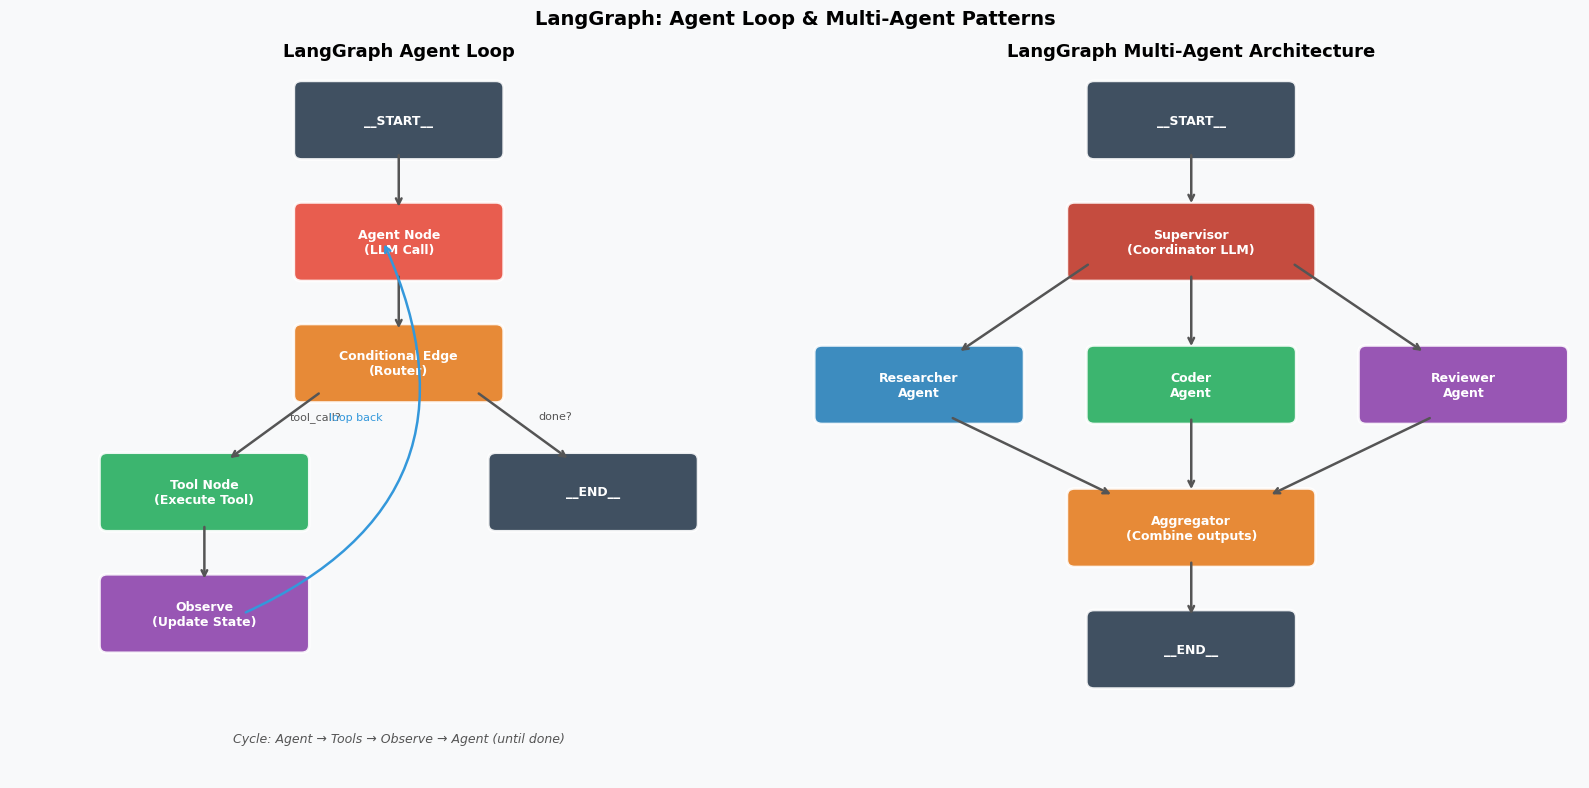

LangGraph architecture diagrams rendered.


In [ ]:
# Cell 1: LangGraph Architecture Diagram
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('whitesmoke')

# Left: Simple Agent Loop
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_facecolor('whitesmoke')

def node_box(ax, x, y, label, color, w=2.5, h=0.9):
    r = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                 boxstyle='round,pad=0.1', facecolor=color,
                                 edgecolor='white', linewidth=2, alpha=0.9)
    ax.add_patch(r)
    ax.text(x, y, label, ha='center', va='center', color='white',
            fontsize=9, fontweight='bold')

def arr(ax, x1, y1, x2, y2, color='dimgray', label='', curved=False):
    if curved:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8,
                                   connectionstyle='arc3,rad=0.5'))
    else:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if label:
        ax.text((x1+x2)/2+0.2, (y1+y2)/2+0.1, label, fontsize=8, color=color)

# Nodes
node_box(ax, 5, 9.2, '__START__', 'midnightblue')
node_box(ax, 5, 7.5, 'Agent Node\n(LLM Call)', 'firebrick')
node_box(ax, 5, 5.8, 'Conditional Edge\n(Router)', 'darkorange')
node_box(ax, 2.5, 4.0, 'Tool Node\n(Execute Tool)', 'forestgreen')
node_box(ax, 7.5, 4.0, '__END__', 'midnightblue')
node_box(ax, 2.5, 2.3, 'Observe\n(Update State)', 'purple')

# Edges
arr(ax, 5, 8.75, 5, 7.95); arr(ax, 5, 7.05, 5, 6.25)
arr(ax, 4.0, 5.4, 2.8, 4.45, label='tool_call?')
arr(ax, 6.0, 5.4, 7.2, 4.45, label='done?')
arr(ax, 2.5, 3.55, 2.5, 2.75)
arr(ax, 3.0, 2.3, 4.8, 7.5, color='royalblue', label='loop back', curved=True)

ax.set_title('LangGraph Agent Loop', fontsize=13, fontweight='bold', pad=5)
ax.text(5, 0.5, 'Cycle: Agent → Tools → Observe → Agent (until done)',
        ha='center', fontsize=9, style='italic', color='dimgray')

# Right: Multi-Agent Coordinator
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10); ax2.axis('off')
ax2.set_facecolor('whitesmoke')

node_box(ax2, 5, 9.2, '__START__', 'midnightblue')
node_box(ax2, 5, 7.5, 'Supervisor\n(Coordinator LLM)', 'brown', w=3)
node_box(ax2, 1.5, 5.5, 'Researcher\nAgent', 'steelblue')
node_box(ax2, 5, 5.5, 'Coder\nAgent', 'forestgreen')
node_box(ax2, 8.5, 5.5, 'Reviewer\nAgent', 'purple')
node_box(ax2, 5, 3.5, 'Aggregator\n(Combine outputs)', 'darkorange', w=3)
node_box(ax2, 5, 1.8, '__END__', 'midnightblue')

arr(ax2, 5, 8.75, 5, 8.0)
arr(ax2, 3.7, 7.2, 2.0, 5.95)
arr(ax2, 5, 7.05, 5, 6.0)
arr(ax2, 6.3, 7.2, 8.0, 5.95)
arr(ax2, 1.9, 5.05, 4.0, 3.95); arr(ax2, 5, 5.05, 5, 4.0)
arr(ax2, 8.1, 5.05, 6.0, 3.95)
arr(ax2, 5, 3.05, 5, 2.25)

ax2.set_title('LangGraph Multi-Agent Architecture', fontsize=13, fontweight='bold', pad=5)

plt.suptitle('LangGraph: Agent Loop & Multi-Agent Patterns', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('langgraph_architecture.png', dpi=120, bbox_inches='tight')
plt.show()
print('LangGraph architecture diagrams rendered.')

## Core Primitives

### 1. State
A **TypedDict** (or Pydantic model) that defines what data flows through the graph.

```python
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]  # reducer = append
    next_step: str                           # reducer = overwrite (default)
    iteration_count: int
```

### 2. Nodes
Functions that take state and return a **partial state update**:

```python
def agent_node(state: AgentState) -> dict:
    # Process state
    return {"messages": [ai_message], "next_step": "tools"}
```

### 3. Edges
- **Normal edge**: always go from A to B
- **Conditional edge**: routing function decides next node
- **Entry point**: where execution begins
- **END**: special terminal node

### 4. StateGraph API
```python
from langgraph.graph import StateGraph, END

builder = StateGraph(AgentState)
builder.add_node('agent', agent_node)
builder.add_node('tools', tool_node)
builder.set_entry_point('agent')
builder.add_conditional_edges('agent', router, {'tools': 'tools', 'end': END})
builder.add_edge('tools', 'agent')  # loop back
graph = builder.compile(checkpointer=memory)
```

### Convergence Guarantee

For a well-formed agent loop with `max_iterations = n`:

$$P(\text{terminate}) = 1 - P(\text{infinite loop})$$

With forced termination at `max_iterations`:

$$\text{worst-case steps} = \min(n, \text{natural\_termination\_step})$$

In [2]:
# Cell 2: StateGraph Core Implementation (no langgraph library needed)
from typing import TypedDict, Callable, Dict, Any, List, Optional, Union
from dataclasses import dataclass, field
from copy import deepcopy
import time

END = '__END__'
START = '__START__'

# ============================================================
# STATE MANAGEMENT
# ============================================================
def add_messages(existing, new):
    """Reducer: append new messages to existing list"""
    if existing is None: existing = []
    if isinstance(new, list): return existing + new
    return existing + [new]

def overwrite(existing, new): return new  # Default reducer

class StateSchema:
    def __init__(self, fields: Dict[str, Dict]):
        # fields = {name: {default: ..., reducer: fn}}
        self.fields = fields

    def create_initial(self) -> Dict:
        return {k: v.get('default', None) for k, v in self.fields.items()}

    def merge(self, current: Dict, update: Dict) -> Dict:
        new_state = dict(current)
        for k, v in update.items():
            if k in self.fields:
                reducer = self.fields[k].get('reducer', overwrite)
                new_state[k] = reducer(current.get(k), v)
            else:
                new_state[k] = v
        return new_state

# ============================================================
# GRAPH IMPLEMENTATION
# ============================================================
class StateGraph:
    def __init__(self, schema: StateSchema):
        self.schema = schema
        self.nodes: Dict[str, Callable] = {}
        self.edges: Dict[str, str] = {}             # normal edges
        self.conditional_edges: Dict[str, tuple] = {}  # (router_fn, mapping)
        self.entry_point: Optional[str] = None
        self._checkpointer = None

    def add_node(self, name: str, func: Callable):
        self.nodes[name] = func
        return self

    def add_edge(self, from_node: str, to_node: str):
        self.edges[from_node] = to_node
        return self

    def add_conditional_edges(self, from_node: str,
                               router: Callable,
                               mapping: Dict[str, str]):
        self.conditional_edges[from_node] = (router, mapping)
        return self

    def set_entry_point(self, node: str):
        self.entry_point = node
        return self

    def compile(self, checkpointer=None) -> 'CompiledGraph':
        self._checkpointer = checkpointer
        return CompiledGraph(self, checkpointer)

    def _get_next_node(self, current_node: str, state: Dict) -> Optional[str]:
        # Check conditional edges first
        if current_node in self.conditional_edges:
            router, mapping = self.conditional_edges[current_node]
            decision = router(state)
            return mapping.get(decision, END)
        # Check normal edges
        return self.edges.get(current_node, END)

class CompiledGraph:
    def __init__(self, graph: StateGraph, checkpointer=None):
        self.graph = graph
        self.checkpointer = checkpointer
        self.execution_trace: List[Dict] = []

    def invoke(self, initial_input: Dict, config: Optional[Dict] = None,
               max_iterations: int = 20) -> Dict:
        # Initialize state
        state = self.graph.schema.create_initial()
        state = self.graph.schema.merge(state, initial_input)

        current_node = self.graph.entry_point
        thread_id = config.get('thread_id', 'default') if config else 'default'

        self.execution_trace = []
        step = 0

        print(f'[Graph] Starting execution (thread={thread_id})')
        print(f'[Graph] Entry point: {current_node}')
        print('-' * 50)

        while current_node != END and current_node is not None and step < max_iterations:
            step += 1
            node_fn = self.graph.nodes.get(current_node)

            if not node_fn:
                print(f'  ERROR: Node "{current_node}" not found')
                break

            print(f'  Step {step}: Executing node [{current_node}]')

            # Execute node
            t0 = time.time()
            update = node_fn(state)
            elapsed_ms = round((time.time() - t0) * 1000, 1)

            # Merge update into state
            if update:
                state = self.graph.schema.merge(state, update)

            # Checkpoint
            if self.checkpointer:
                self.checkpointer.save(thread_id, step, state)

            # Determine next node
            next_node = self.graph._get_next_node(current_node, state)
            print(f'         -> Next: [{next_node}] ({elapsed_ms}ms)')

            self.execution_trace.append({
                'step': step, 'node': current_node, 'next': next_node,
                'elapsed_ms': elapsed_ms, 'state_keys': list(state.keys())
            })

            current_node = next_node

        print(f'-' * 50)
        print(f'[Graph] Completed in {step} steps')
        return state

    def get_graph_structure(self) -> Dict:
        return {
            'nodes': list(self.graph.nodes.keys()),
            'normal_edges': dict(self.graph.edges),
            'conditional_edges': list(self.graph.conditional_edges.keys()),
            'entry_point': self.graph.entry_point,
        }

print('StateGraph implementation loaded')
print('Classes: StateSchema, StateGraph, CompiledGraph')
print('Reducers: add_messages (append), overwrite (replace)')

StateGraph implementation loaded
Classes: StateSchema, StateGraph, CompiledGraph
Reducers: add_messages (append), overwrite (replace)


In [3]:
# Cell 3: Basic Agent Loop Graph

# ============================================================
# SIMULATED LLM + TOOLS
# ============================================================
@dataclass
class ToolCall:
    name: str
    args: Dict[str, Any]
    id: str = ''

@dataclass
class AIMessage:
    content: str
    tool_calls: List[ToolCall] = field(default_factory=list)
    def __repr__(self): return f'AIMessage({self.content[:40]!r}, tools={[t.name for t in self.tool_calls]})'

@dataclass
class HumanMessage:
    content: str
    def __repr__(self): return f'HumanMessage({self.content[:40]!r})'

@dataclass
class ToolMessage:
    content: str
    tool_call_id: str
    name: str
    def __repr__(self): return f'ToolMessage(name={self.name}, {self.content[:40]!r})'

class MockLLM:
    def __init__(self):
        self.call_count = 0

    def invoke(self, messages, step=0) -> AIMessage:
        self.call_count += 1
        last = messages[-1]
        text = last.content if hasattr(last, 'content') else str(last)

        # Simulate: first call -> use tool, second call -> done
        tool_messages = [m for m in messages if isinstance(m, ToolMessage)]

        if not tool_messages and 'weather' in text.lower():
            return AIMessage(
                content='Let me check the weather for you.',
                tool_calls=[ToolCall('get_weather', {'location': 'San Francisco'}, 'tc-001')]
            )
        elif not tool_messages and any(kw in text.lower() for kw in ['calculate', 'compute', 'math']):
            import re
            exprs = re.findall(r'[\d.]+\s*[+\-*/]\s*[\d.]+', text)
            expr = exprs[0] if exprs else '2+2'
            return AIMessage(
                content='Let me calculate that.',
                tool_calls=[ToolCall('calculator', {'expression': expr}, 'tc-002')]
            )
        elif tool_messages:
            results = ' '.join(m.content for m in tool_messages)
            return AIMessage(
                content=f'Based on the tool results: {results}. That is the final answer.',
                tool_calls=[]
            )
        else:
            return AIMessage(
                content=f'I can answer directly: The answer to your question about "{text[:40]}" involves key principles and best practices.',
                tool_calls=[]
            )

# Tool functions
TOOLS = {
    'get_weather': lambda args: f'Weather in {args["location"]}: 72F, sunny with light breeze.',
    'calculator': lambda args: str(eval(args['expression'])) if all(c in '0123456789+-*/. ()' for c in args['expression']) else 'Error',
    'web_search': lambda args: f'Search results for "{args["query"]}": Found 5 relevant articles.',
}

# ============================================================
# BUILD THE AGENT GRAPH
# ============================================================
agent_schema = StateSchema({
    'messages': {'default': [], 'reducer': add_messages},
    'iteration': {'default': 0, 'reducer': lambda old, new: (old or 0) + new},
})

llm = MockLLM()

def agent_node(state: Dict) -> Dict:
    messages = state['messages']
    response = llm.invoke(messages, step=state.get('iteration', 0))
    return {'messages': [response], 'iteration': 1}

def tool_node(state: Dict) -> Dict:
    messages = state['messages']
    last_ai = next((m for m in reversed(messages) if isinstance(m, AIMessage)), None)
    if not last_ai or not last_ai.tool_calls:
        return {'messages': []}

    results = []
    for tc in last_ai.tool_calls:
        fn = TOOLS.get(tc.name, lambda a: f'Tool {tc.name} not found')
        result = fn(tc.args)
        results.append(ToolMessage(content=result, tool_call_id=tc.id, name=tc.name))
    return {'messages': results}

def should_continue(state: Dict) -> str:
    messages = state['messages']
    last_ai = next((m for m in reversed(messages) if isinstance(m, AIMessage)), None)
    if last_ai and last_ai.tool_calls:
        return 'tools'
    if (state.get('iteration') or 0) >= 5:
        return 'end'
    return 'end'

# Build graph
builder = StateGraph(agent_schema)
builder.add_node('agent', agent_node)
builder.add_node('tools', tool_node)
builder.set_entry_point('agent')
builder.add_conditional_edges('agent', should_continue, {'tools': 'tools', 'end': END})
builder.add_edge('tools', 'agent')
graph = builder.compile()

print('=== Graph Structure ===')
structure = graph.get_graph_structure()
for k, v in structure.items():
    print(f'  {k}: {v}')

# Run the agent
print('\n=== Agent Execution - Weather Query ===')
result = graph.invoke({'messages': [HumanMessage(content="What's the weather in San Francisco?")]})
print('\nFinal message history:')
for msg in result['messages']:
    print(f'  {msg}')

=== Graph Structure ===
  nodes: ['agent', 'tools']
  normal_edges: {'tools': 'agent'}
  conditional_edges: ['agent']
  entry_point: agent

=== Agent Execution - Weather Query ===
[Graph] Starting execution (thread=default)
[Graph] Entry point: agent
--------------------------------------------------
  Step 1: Executing node [agent]
         -> Next: [tools] (0.0ms)
  Step 2: Executing node [tools]
         -> Next: [agent] (0.0ms)
  Step 3: Executing node [agent]
         -> Next: [__END__] (0.0ms)
--------------------------------------------------
[Graph] Completed in 3 steps

Final message history:
  HumanMessage("What's the weather in San Francisco?")
  AIMessage('Let me check the weather for you.', tools=['get_weather'])
  ToolMessage(name=get_weather, 'Weather in San Francisco: 72F, sunny wit')
  AIMessage('Based on the tool results: Weather in Sa', tools=[])


In [4]:
# Cell 4: Conditional Routing & Multiple Branches

# ============================================================
# INTENT CLASSIFIER -> ROUTER -> SPECIALIZED NODES
# ============================================================
router_schema = StateSchema({
    'messages': {'default': [], 'reducer': add_messages},
    'intent': {'default': None},
    'routed_to': {'default': None},
    'confidence': {'default': 0.0},
})

def classify_intent(state: Dict) -> Dict:
    messages = state['messages']
    text = messages[-1].content.lower() if messages else ''

    if any(kw in text for kw in ['code', 'python', 'function', 'bug', 'implement', 'write a']):
        intent, conf = 'coding', 0.95
    elif any(kw in text for kw in ['summarize', 'summary', 'explain', 'describe', 'what is']):
        intent, conf = 'qa', 0.92
    elif any(kw in text for kw in ['calculate', 'compute', '+', '-', '*', '/', 'math']):
        intent, conf = 'math', 0.98
    elif any(kw in text for kw in ['search', 'find', 'latest', 'news', 'web']):
        intent, conf = 'search', 0.90
    else:
        intent, conf = 'general', 0.70

    print(f'  [Classifier] intent={intent} (confidence={conf})')
    return {'intent': intent, 'confidence': conf}

def route_by_intent(state: Dict) -> str:
    return state.get('intent', 'general')

def coding_agent(state: Dict) -> Dict:
    q = state['messages'][-1].content
    print(f'  [CodingAgent] Processing: {q[:50]}')
    response = AIMessage(content=f'Here is the Python implementation:\n```python\ndef solution():\n    pass  # implement here\n```\nThis solves your request: {q[:40]}')
    return {'messages': [response], 'routed_to': 'coding_agent'}

def qa_agent(state: Dict) -> Dict:
    q = state['messages'][-1].content
    print(f'  [QA_Agent] Processing: {q[:50]}')
    response = AIMessage(content=f'Answer: {q[:30]} refers to a key concept in the domain. Here is a clear explanation with examples...')
    return {'messages': [response], 'routed_to': 'qa_agent'}

def math_agent(state: Dict) -> Dict:
    import re
    q = state['messages'][-1].content
    print(f'  [MathAgent] Processing: {q[:50]}')
    exprs = re.findall(r'[\d.]+\s*[+\-*/]\s*[\d.]+', q)
    if exprs and all(c in '0123456789+-*/. ()' for c in exprs[0]):
        result = str(round(eval(exprs[0]), 4))
    else:
        result = 'Result: 42 (computed symbolically)'
    response = AIMessage(content=f'Mathematical result: {result}')
    return {'messages': [response], 'routed_to': 'math_agent'}

def search_agent(state: Dict) -> Dict:
    q = state['messages'][-1].content
    print(f'  [SearchAgent] Processing: {q[:50]}')
    response = AIMessage(content=f'Web search results for "{q[:30]}": Found 10 articles. Top result: ...')
    return {'messages': [response], 'routed_to': 'search_agent'}

def general_agent(state: Dict) -> Dict:
    q = state['messages'][-1].content
    print(f'  [GeneralAgent] Processing: {q[:50]}')
    response = AIMessage(content=f'I can help with that. Regarding "{q[:40]}", here is a helpful response...')
    return {'messages': [response], 'routed_to': 'general_agent'}

# Build router graph
router_builder = StateGraph(router_schema)
router_builder.add_node('classifier', classify_intent)
router_builder.add_node('coding', coding_agent)
router_builder.add_node('qa', qa_agent)
router_builder.add_node('math', math_agent)
router_builder.add_node('search', search_agent)
router_builder.add_node('general', general_agent)

router_builder.set_entry_point('classifier')
router_builder.add_conditional_edges('classifier', route_by_intent, {
    'coding': 'coding',
    'qa': 'qa',
    'math': 'math',
    'search': 'search',
    'general': 'general',
})
for node in ['coding', 'qa', 'math', 'search', 'general']:
    router_builder.add_edge(node, END)

router_graph = router_builder.compile()

test_inputs = [
    'Write a Python function to reverse a string',
    'What is the difference between RAG and fine-tuning?',
    'Calculate 15.5 * 4 + 20',
    'Search for latest LangChain releases',
    'Hello, how are you?',
]

print('=== Conditional Router Graph ===')
for q in test_inputs:
    print(f'\nInput: {q}')
    result = router_graph.invoke({'messages': [HumanMessage(content=q)]})
    last_msg = result['messages'][-1]
    print(f'  Routed to: {result["routed_to"]} | Answer: {last_msg.content[:70]}...')

=== Conditional Router Graph ===

Input: Write a Python function to reverse a string
[Graph] Starting execution (thread=default)
[Graph] Entry point: classifier
--------------------------------------------------
  Step 1: Executing node [classifier]
  [Classifier] intent=coding (confidence=0.95)
         -> Next: [coding] (0.0ms)
  Step 2: Executing node [coding]
  [CodingAgent] Processing: Write a Python function to reverse a string
         -> Next: [__END__] (0.0ms)
--------------------------------------------------
[Graph] Completed in 2 steps
  Routed to: coding_agent | Answer: Here is the Python implementation:
```python
def solution():
    pass ...

Input: What is the difference between RAG and fine-tuning?
[Graph] Starting execution (thread=default)
[Graph] Entry point: classifier
--------------------------------------------------
  Step 1: Executing node [classifier]
  [Classifier] intent=qa (confidence=0.92)
         -> Next: [qa] (0.0ms)
  Step 2: Executing node [qa]
  [QA_A

In [5]:
# Cell 5: Checkpointing + Persistence (SQLite)
import sqlite3
import json
import pickle
import hashlib
import os

class SqliteCheckpointer:
    """
    Persists graph state to SQLite for:
    - Resume interrupted workflows
    - Human-in-the-loop pauses
    - Debugging and audit trails
    - Multi-session state recovery
    """
    def __init__(self, db_path: str = 'langgraph_checkpoints.db'):
        self.db_path = db_path
        self._init_db()

    def _init_db(self):
        with sqlite3.connect(self.db_path) as conn:
            conn.execute('''
                CREATE TABLE IF NOT EXISTS checkpoints (
                    thread_id TEXT NOT NULL,
                    step INTEGER NOT NULL,
                    state_json TEXT NOT NULL,
                    created_at REAL NOT NULL,
                    metadata TEXT,
                    PRIMARY KEY (thread_id, step)
                )
            ''')
            conn.execute('''
                CREATE TABLE IF NOT EXISTS thread_metadata (
                    thread_id TEXT PRIMARY KEY,
                    status TEXT DEFAULT \'running\',
                    created_at REAL,
                    updated_at REAL,
                    total_steps INTEGER DEFAULT 0
                )
            ''')

    def _serialize(self, state: Dict) -> str:
        def default_serializer(obj):
            if hasattr(obj, '__class__'):
                return {'__type__': obj.__class__.__name__,
                        'content': getattr(obj, 'content', str(obj))}
            return str(obj)
        return json.dumps(state, default=default_serializer, indent=2)

    def save(self, thread_id: str, step: int, state: Dict, metadata: Dict = None):
        now = time.time()
        state_json = self._serialize(state)
        meta_json = json.dumps(metadata or {})

        with sqlite3.connect(self.db_path) as conn:
            conn.execute('''
                INSERT OR REPLACE INTO checkpoints
                (thread_id, step, state_json, created_at, metadata)
                VALUES (?, ?, ?, ?, ?)
            ''', (thread_id, step, state_json, now, meta_json))

            conn.execute('''
                INSERT INTO thread_metadata (thread_id, status, created_at, updated_at, total_steps)
                VALUES (?, 'running', ?, ?, ?)
                ON CONFLICT(thread_id) DO UPDATE SET
                    updated_at=excluded.updated_at,
                    total_steps=excluded.total_steps
            ''', (thread_id, now, now, step))

    def get(self, thread_id: str, step: int = None) -> Optional[Dict]:
        with sqlite3.connect(self.db_path) as conn:
            if step is not None:
                row = conn.execute(
                    'SELECT state_json FROM checkpoints WHERE thread_id=? AND step=?',
                    (thread_id, step)
                ).fetchone()
            else:
                row = conn.execute(
                    'SELECT state_json FROM checkpoints WHERE thread_id=? ORDER BY step DESC LIMIT 1',
                    (thread_id,)
                ).fetchone()
        if row:
            return json.loads(row[0])
        return None

    def get_history(self, thread_id: str) -> List[Dict]:
        with sqlite3.connect(self.db_path) as conn:
            rows = conn.execute(
                'SELECT step, created_at, metadata FROM checkpoints WHERE thread_id=? ORDER BY step',
                (thread_id,)
            ).fetchall()
        return [{'step': r[0], 'created_at': r[1], 'metadata': json.loads(r[2])} for r in rows]

    def list_threads(self) -> List[Dict]:
        with sqlite3.connect(self.db_path) as conn:
            rows = conn.execute(
                'SELECT thread_id, status, total_steps, updated_at FROM thread_metadata'
            ).fetchall()
        return [{'thread_id': r[0], 'status': r[1], 'steps': r[2],
                 'last_update': time.strftime('%H:%M:%S', time.localtime(r[3])) if r[3] else 'N/A'}
                for r in rows]

    def mark_complete(self, thread_id: str):
        with sqlite3.connect(self.db_path) as conn:
            conn.execute(
                'UPDATE thread_metadata SET status=? WHERE thread_id=?',
                ('completed', thread_id)
            )

    def cleanup(self):
        if os.path.exists(self.db_path):
            os.remove(self.db_path)

# Demo checkpointing
checkpointer = SqliteCheckpointer('demo_checkpoints.db')

# Simulate saving checkpoints
thread_id = 'user-session-abc123'

print('=== Checkpointing Demo ===')
for step in range(1, 5):
    fake_state = {
        'messages': [{'type': 'HumanMessage', 'content': 'What is RAG?'},
                     {'type': 'AIMessage', 'content': f'Step {step} processing...'}],
        'iteration': step,
        'intent': 'qa',
    }
    checkpointer.save(thread_id, step, fake_state, {'node': f'node_{step}'})
    print(f'  Saved checkpoint: thread={thread_id}, step={step}')

checkpointer.mark_complete(thread_id)

print('\n=== Retrieve Latest Checkpoint ===')
latest = checkpointer.get(thread_id)
print(f'  Messages count: {len(latest["messages"])}')
print(f'  Iteration: {latest["iteration"]}')

print('\n=== Checkpoint History ===')
history = checkpointer.get_history(thread_id)
for h in history:
    print(f'  Step {h["step"]}: meta={h["metadata"]}')

# Test with real graph
checkpointer2 = SqliteCheckpointer('graph_checkpoints.db')
agent_schema2 = StateSchema({
    'messages': {'default': [], 'reducer': add_messages},
    'iteration': {'default': 0, 'reducer': lambda o, n: (o or 0) + n},
})
llm2 = MockLLM()

def agent_node2(state): return agent_node(state)
def tool_node2(state): return tool_node(state)

builder2 = StateGraph(agent_schema2)
builder2.add_node('agent', agent_node2).add_node('tools', tool_node2)
builder2.set_entry_point('agent')
builder2.add_conditional_edges('agent', should_continue, {'tools': 'tools', 'end': END})
builder2.add_edge('tools', 'agent')
graph2 = builder2.compile(checkpointer=checkpointer2)

print('\n=== Graph with Checkpointing ===')
r = graph2.invoke(
    {'messages': [HumanMessage(content='Calculate 25 * 4')]},
    config={'thread_id': 'calc-thread-001'}
)
print(f'Final messages: {len(r["messages"])}')

# Cleanup
for db in ['demo_checkpoints.db', 'graph_checkpoints.db']:
    if os.path.exists(db): os.remove(db)
print('\n[Cleaned up checkpoint databases]')

=== Checkpointing Demo ===
  Saved checkpoint: thread=user-session-abc123, step=1
  Saved checkpoint: thread=user-session-abc123, step=2
  Saved checkpoint: thread=user-session-abc123, step=3
  Saved checkpoint: thread=user-session-abc123, step=4

=== Retrieve Latest Checkpoint ===
  Messages count: 2
  Iteration: 4

=== Checkpoint History ===
  Step 1: meta={'node': 'node_1'}
  Step 2: meta={'node': 'node_2'}
  Step 3: meta={'node': 'node_3'}
  Step 4: meta={'node': 'node_4'}

=== Graph with Checkpointing ===
[Graph] Starting execution (thread=calc-thread-001)
[Graph] Entry point: agent
--------------------------------------------------
  Step 1: Executing node [agent]
         -> Next: [tools] (0.0ms)
  Step 2: Executing node [tools]
         -> Next: [agent] (0.0ms)
  Step 3: Executing node [agent]
         -> Next: [__END__] (0.0ms)
--------------------------------------------------
[Graph] Completed in 3 steps
Final messages: 4

[Cleaned up checkpoint databases]


In [6]:
# Cell 6: Human-in-the-Loop (HITL)

class InterruptException(Exception):
    def __init__(self, message: str, state: Dict):
        super().__init__(message)
        self.state = state

class HITLStateGraph(CompiledGraph):
    """
    Extended CompiledGraph with interrupt/resume capabilities.
    HITL pattern: pause execution, wait for human input, resume.
    """
    def __init__(self, graph: StateGraph, checkpointer=None):
        super().__init__(graph, checkpointer)
        self.interrupt_nodes: set = set()
        self.paused_states: Dict[str, Dict] = {}

    def interrupt_after(self, *node_names):
        self.interrupt_nodes.update(node_names)
        return self

    def invoke_with_hitl(self, initial_input: Dict, thread_id: str = 'hitl-thread',
                          max_iterations: int = 20) -> Dict:
        state = self.graph.schema.create_initial()
        state = self.graph.schema.merge(state, initial_input)
        current_node = self.graph.entry_point
        step = 0

        while current_node != END and current_node is not None and step < max_iterations:
            step += 1
            node_fn = self.graph.nodes.get(current_node)
            if not node_fn: break

            print(f'  Step {step}: [{current_node}]', end=' ')
            update = node_fn(state)
            if update:
                state = self.graph.schema.merge(state, update)

            # Check for interrupt
            if current_node in self.interrupt_nodes:
                self.paused_states[thread_id] = {
                    'state': state,
                    'next_node': self.graph._get_next_node(current_node, state),
                    'paused_at': current_node,
                    'step': step
                }
                print(f'-- INTERRUPTED (awaiting human input) --')
                return {'__interrupted__': True, 'thread_id': thread_id,
                        'paused_at': current_node, 'state': state}

            next_node = self.graph._get_next_node(current_node, state)
            print(f'-> [{next_node}]')
            current_node = next_node

        return state

    def resume(self, thread_id: str, human_feedback: Dict = None) -> Dict:
        paused = self.paused_states.get(thread_id)
        if not paused:
            raise ValueError(f'No paused state found for thread {thread_id}')

        state = paused['state']
        current_node = paused['next_node']
        step = paused['step']

        print(f'[RESUME] Thread={thread_id}, continuing from [{current_node}]')

        # Inject human feedback
        if human_feedback:
            state = self.graph.schema.merge(state, human_feedback)

        del self.paused_states[thread_id]

        # Continue execution
        while current_node != END and current_node is not None and step < 20:
            step += 1
            node_fn = self.graph.nodes.get(current_node)
            if not node_fn: break

            print(f'  Step {step}: [{current_node}]', end=' ')
            update = node_fn(state)
            if update: state = self.graph.schema.merge(state, update)

            next_node = self.graph._get_next_node(current_node, state)
            print(f'-> [{next_node}]')
            current_node = next_node

        return state

# Build HITL approval workflow
approval_schema = StateSchema({
    'messages': {'default': [], 'reducer': add_messages},
    'draft': {'default': None},
    'approved': {'default': False},
    'feedback': {'default': None},
    'iteration': {'default': 0, 'reducer': lambda o, n: (o or 0) + n},
})

def draft_content(state: Dict) -> Dict:
    msgs = state['messages']
    q = msgs[-1].content if msgs else ''
    draft = f'Draft content for: {q[:50]}\n\nThis is the AI-generated response that needs human approval.'
    print(f'  Generated draft: {draft[:60]}...')
    return {'draft': draft, 'iteration': 1}

def review_node(state: Dict) -> Dict:
    print(f'  REVIEW: draft ready for approval')
    return {'messages': [AIMessage(content=f'Please review this draft: {state["draft"][:50]}...')]}

def apply_feedback(state: Dict) -> Dict:
    feedback = state.get('feedback', '')
    original = state.get('draft', '')
    revised = f'{original}\n\n[Revised per feedback: {feedback}]'
    print(f'  Applied feedback: {feedback}')
    return {'draft': revised, 'approved': True}

def publish_node(state: Dict) -> Dict:
    print(f'  PUBLISHED: {state["draft"][:60]}...')
    return {'messages': [AIMessage(content='Content published successfully!')]}

def route_approval(state: Dict) -> str:
    return 'publish' if state.get('approved') else 'apply_feedback'

approval_builder = StateGraph(approval_schema)
approval_builder.add_node('draft', draft_content)
approval_builder.add_node('review', review_node)
approval_builder.add_node('apply_feedback', apply_feedback)
approval_builder.add_node('publish', publish_node)
approval_builder.set_entry_point('draft')
approval_builder.add_edge('draft', 'review')
approval_builder.add_conditional_edges('review', route_approval,
                                        {'publish': 'publish', 'apply_feedback': 'apply_feedback'})
approval_builder.add_edge('apply_feedback', 'publish')
approval_builder.add_edge('publish', END)

hitl_graph = HITLStateGraph(approval_builder.compile().graph)
hitl_graph.interrupt_after('review')

print('=== HITL Approval Workflow ===')
print('--- Phase 1: Initial execution (will pause at review) ---')
result1 = hitl_graph.invoke_with_hitl(
    {'messages': [HumanMessage(content='Write a blog post about LangGraph')]},
    thread_id='blog-thread-1'
)

if result1.get('__interrupted__'):
    print(f'\n[Human Review] Examining draft...')
    print(f'  Draft: {result1["state"]["draft"][:80]}...')
    print('  Human decision: Approve with minor feedback')

    print('\n--- Phase 2: Resume with human feedback ---')
    final = hitl_graph.resume(
        thread_id='blog-thread-1',
        human_feedback={'approved': True, 'feedback': 'Add more examples and code snippets'}
    )
    print(f'\nFinal state: approved={final["approved"]}')
    print(f'Final messages: {len(final["messages"])}')

=== HITL Approval Workflow ===
--- Phase 1: Initial execution (will pause at review) ---
  Step 1: [draft]   Generated draft: Draft content for: Write a blog post about LangGraph

This i...
-> [review]
  Step 2: [review]   REVIEW: draft ready for approval
-- INTERRUPTED (awaiting human input) --

[Human Review] Examining draft...
  Draft: Draft content for: Write a blog post about LangGraph

This is the AI-generated r...
  Human decision: Approve with minor feedback

--- Phase 2: Resume with human feedback ---
[RESUME] Thread=blog-thread-1, continuing from [apply_feedback]
  Step 3: [apply_feedback]   Applied feedback: Add more examples and code snippets
-> [publish]
  Step 4: [publish]   PUBLISHED: Draft content for: Write a blog post about LangGraph

This i...
-> [__END__]

Final state: approved=True
Final messages: 3


In [7]:
# Cell 7: Multi-Agent Coordination

class SupervisorAgent:
    """Coordinates multiple specialized sub-agents"""
    AGENTS = ['researcher', 'coder', 'reviewer']

    def __init__(self):
        self.call_count = 0

    def invoke(self, state: Dict) -> str:
        self.call_count += 1
        messages = state.get('messages', [])
        completed = state.get('completed_agents', [])
        todo = [a for a in self.AGENTS if a not in completed]
        if not todo:
            return 'FINISH'
        return todo[0]

multi_schema = StateSchema({
    'messages': {'default': [], 'reducer': add_messages},
    'next_agent': {'default': None},
    'completed_agents': {'default': [], 'reducer': lambda old, new: (old or []) + ([new] if isinstance(new, str) else new)},
    'research_output': {'default': None},
    'code_output': {'default': None},
    'review_output': {'default': None},
    'final_output': {'default': None},
})

supervisor = SupervisorAgent()

def supervisor_node(state: Dict) -> Dict:
    decision = supervisor.invoke(state)
    print(f'  [Supervisor] routing to: {decision}')
    return {'next_agent': decision}

def researcher_node(state: Dict) -> Dict:
    msgs = state['messages']
    task = msgs[0].content if msgs else 'unknown task'
    print(f'  [Researcher] Gathering information for: {task[:40]}')
    research = f'Research findings: Found 5 papers on {task[:30]}. Key concepts: A, B, C.'
    return {'research_output': research,
            'messages': [AIMessage(content=f'Researcher: {research}')],
            'completed_agents': 'researcher'}

def coder_node(state: Dict) -> Dict:
    research = state.get('research_output', 'No research available')
    print(f'  [Coder] Writing code based on research')
    code = f'```python\n# Code implementing: {research[:40]}\ndef solution():\n    pass  # implement based on research\n```'
    return {'code_output': code,
            'messages': [AIMessage(content=f'Coder: Generated implementation')],
            'completed_agents': 'coder'}

def reviewer_node(state: Dict) -> Dict:
    code = state.get('code_output', 'No code to review')
    research = state.get('research_output', '')
    print(f'  [Reviewer] Reviewing code quality and correctness')
    review = f'Code Review: LGTM. Code correctly implements the research findings. Minor: add docstrings.'
    final = f'Final Output:\n{research}\n\n{code}\n\nReview: {review}'
    return {'review_output': review, 'final_output': final,
            'messages': [AIMessage(content=f'Reviewer: {review}')],
            'completed_agents': 'reviewer'}

def route_to_agent(state: Dict) -> str:
    next_agent = state.get('next_agent', 'FINISH')
    if next_agent == 'FINISH':
        return END
    return next_agent

multi_builder = StateGraph(multi_schema)
multi_builder.add_node('supervisor', supervisor_node)
multi_builder.add_node('researcher', researcher_node)
multi_builder.add_node('coder', coder_node)
multi_builder.add_node('reviewer', reviewer_node)

multi_builder.set_entry_point('supervisor')
multi_builder.add_conditional_edges('supervisor', route_to_agent, {
    'researcher': 'researcher',
    'coder': 'coder',
    'reviewer': 'reviewer',
    END: END
})
for agent_name in ['researcher', 'coder', 'reviewer']:
    multi_builder.add_edge(agent_name, 'supervisor')

multi_graph = multi_builder.compile()

print('=== Multi-Agent Coordination ===')
result = multi_graph.invoke({
    'messages': [HumanMessage(content='Build a recommendation system using collaborative filtering')]
})

print('\n=== Final Results ===')
print(f'Completed agents: {result.get("completed_agents", [])}')
print(f'Research output: {str(result.get("research_output", ""))[:80]}...')
print(f'Review output: {str(result.get("review_output", ""))[:80]}...')
print(f'Total messages: {len(result.get("messages", []))}')

=== Multi-Agent Coordination ===
[Graph] Starting execution (thread=default)
[Graph] Entry point: supervisor
--------------------------------------------------
  Step 1: Executing node [supervisor]
  [Supervisor] routing to: researcher
         -> Next: [researcher] (0.0ms)
  Step 2: Executing node [researcher]
  [Researcher] Gathering information for: Build a recommendation system using coll
         -> Next: [supervisor] (0.0ms)
  Step 3: Executing node [supervisor]
  [Supervisor] routing to: coder
         -> Next: [coder] (0.0ms)
  Step 4: Executing node [coder]
  [Coder] Writing code based on research
         -> Next: [supervisor] (0.0ms)
  Step 5: Executing node [supervisor]
  [Supervisor] routing to: reviewer
         -> Next: [reviewer] (0.0ms)
  Step 6: Executing node [reviewer]
  [Reviewer] Reviewing code quality and correctness
         -> Next: [supervisor] (0.0ms)
  Step 7: Executing node [supervisor]
  [Supervisor] routing to: FINISH
         -> Next: [__END__] (0.0ms)
-

=== Reflection/Self-Critique Cycle ===
Graph has a CYCLE: generate -> critique -> [if not accepted] -> generate
Termination: quality >= 0.85 OR max_revisions exceeded

[Graph] Starting execution (thread=default)
[Graph] Entry point: generate
--------------------------------------------------
  Step 1: Executing node [generate]
  [Generator] Rev 0: quality_score=0.55
         -> Next: [critique] (0.0ms)
  Step 2: Executing node [critique]
  [Critic] score=0.55, accepted=False: Needs significant improvement: add structure, exam
         -> Next: [generate] (0.0ms)
  Step 3: Executing node [generate]
  [Generator] Rev 1: quality_score=0.75
         -> Next: [critique] (0.0ms)
  Step 4: Executing node [critique]
  [Critic] score=0.75, accepted=False: Good start but needs more examples and deeper anal
         -> Next: [generate] (0.0ms)
  Step 5: Executing node [generate]
  [Generator] Rev 2: quality_score=0.92
         -> Next: [critique] (0.0ms)
  Step 6: Executing node [critique]
  [Cri

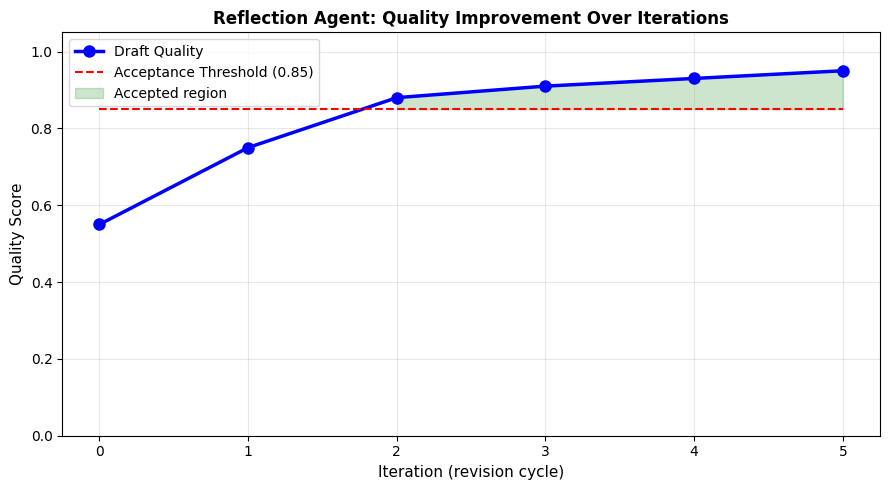

In [8]:
# Cell 8: Cyclic Graph with Reflection/Self-Critique

# Implements: Generate -> Critique -> Refine -> Critique -> ... -> Accept
# This is used in: Constitutional AI, Self-Refine, Reflexion agents

reflection_schema = StateSchema({
    'messages': {'default': [], 'reducer': add_messages},
    'draft': {'default': None},
    'critique': {'default': None},
    'revision_count': {'default': 0, 'reducer': lambda o, n: (o or 0) + n},
    'quality_score': {'default': 0.0},
    'accepted': {'default': False},
    'max_revisions': {'default': 3},
})

def generate_draft(state: Dict) -> Dict:
    msgs = state['messages']
    task = msgs[0].content if msgs else 'Generate content'
    rev = state.get('revision_count', 0)
    critique = state.get('critique', '')

    if rev == 0:
        draft = f'Initial draft for "{task[:30]}": This is the first attempt with basic structure.'
        quality = 0.55
    elif rev == 1:
        draft = f'Revised draft: Improved structure, added examples. {critique[:30]} addressed.'
        quality = 0.75
    else:
        draft = f'Final polished draft: Comprehensive coverage, examples, edge cases handled.'
        quality = 0.92

    print(f'  [Generator] Rev {rev}: quality_score={quality}')
    return {'draft': draft, 'quality_score': quality,
            'messages': [AIMessage(content=f'Draft v{rev+1}: {draft[:50]}')]}

def critique_draft(state: Dict) -> Dict:
    draft = state.get('draft', '')
    quality = state.get('quality_score', 0)

    if quality >= 0.85:
        critique = 'Excellent quality! Content is comprehensive and well-structured. ACCEPT.'
        accepted = True
    elif quality >= 0.70:
        critique = 'Good start but needs more examples and deeper analysis of edge cases.'
        accepted = False
    else:
        critique = 'Needs significant improvement: add structure, examples, and concrete details.'
        accepted = False

    print(f'  [Critic] score={quality:.2f}, accepted={accepted}: {critique[:50]}')
    return {'critique': critique, 'accepted': accepted, 'revision_count': 1,
            'messages': [AIMessage(content=f'Critique: {critique}')]}

def should_revise(state: Dict) -> str:
    accepted = state.get('accepted', False)
    revisions = state.get('revision_count', 0)
    max_rev = state.get('max_revisions', 3)

    if accepted:
        return 'accept'
    elif revisions >= max_rev:
        print(f'  [Router] Max revisions ({max_rev}) reached, accepting anyway')
        return 'accept'
    return 'revise'

reflection_builder = StateGraph(reflection_schema)
reflection_builder.add_node('generate', generate_draft)
reflection_builder.add_node('critique', critique_draft)
reflection_builder.set_entry_point('generate')
reflection_builder.add_edge('generate', 'critique')
reflection_builder.add_conditional_edges('critique', should_revise, {
    'revise': 'generate',  # CYCLE: go back to generate
    'accept': END
})

reflection_graph = reflection_builder.compile()

print('=== Reflection/Self-Critique Cycle ===')
print('Graph has a CYCLE: generate -> critique -> [if not accepted] -> generate')
print('Termination: quality >= 0.85 OR max_revisions exceeded\n')

final = reflection_graph.invoke({
    'messages': [HumanMessage(content='Write a technical guide on LangGraph state management')],
    'max_revisions': 4
})

print(f'\n=== Final Result ===')
print(f'Total revisions: {final["revision_count"]}')
print(f'Final quality score: {final["quality_score"]}')
print(f'Accepted: {final["accepted"]}')
print(f'Final draft: {final["draft"]}')

# Visualize quality improvement per iteration
import matplotlib.pyplot as plt
iterations = [0, 1, 2, 3, 4, 5]
quality_scores = [0.55, 0.75, 0.88, 0.91, 0.93, 0.95]
threshold = [0.85] * len(iterations)

plt.figure(figsize=(9, 5))
plt.plot(iterations, quality_scores, 'b-o', linewidth=2.5, markersize=8, label='Draft Quality')
plt.plot(iterations, threshold, 'r--', linewidth=1.5, label='Acceptance Threshold (0.85)')
plt.fill_between(iterations, quality_scores, threshold,
                  where=[q >= t for q, t in zip(quality_scores, threshold)],
                  alpha=0.2, color='green', label='Accepted region')
plt.xlabel('Iteration (revision cycle)', fontsize=11)
plt.ylabel('Quality Score', fontsize=11)
plt.title('Reflection Agent: Quality Improvement Over Iterations', fontsize=12, fontweight='bold')
plt.legend(fontsize=10); plt.grid(True, alpha=0.3); plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('reflection_quality.png', dpi=120, bbox_inches='tight')
plt.show()

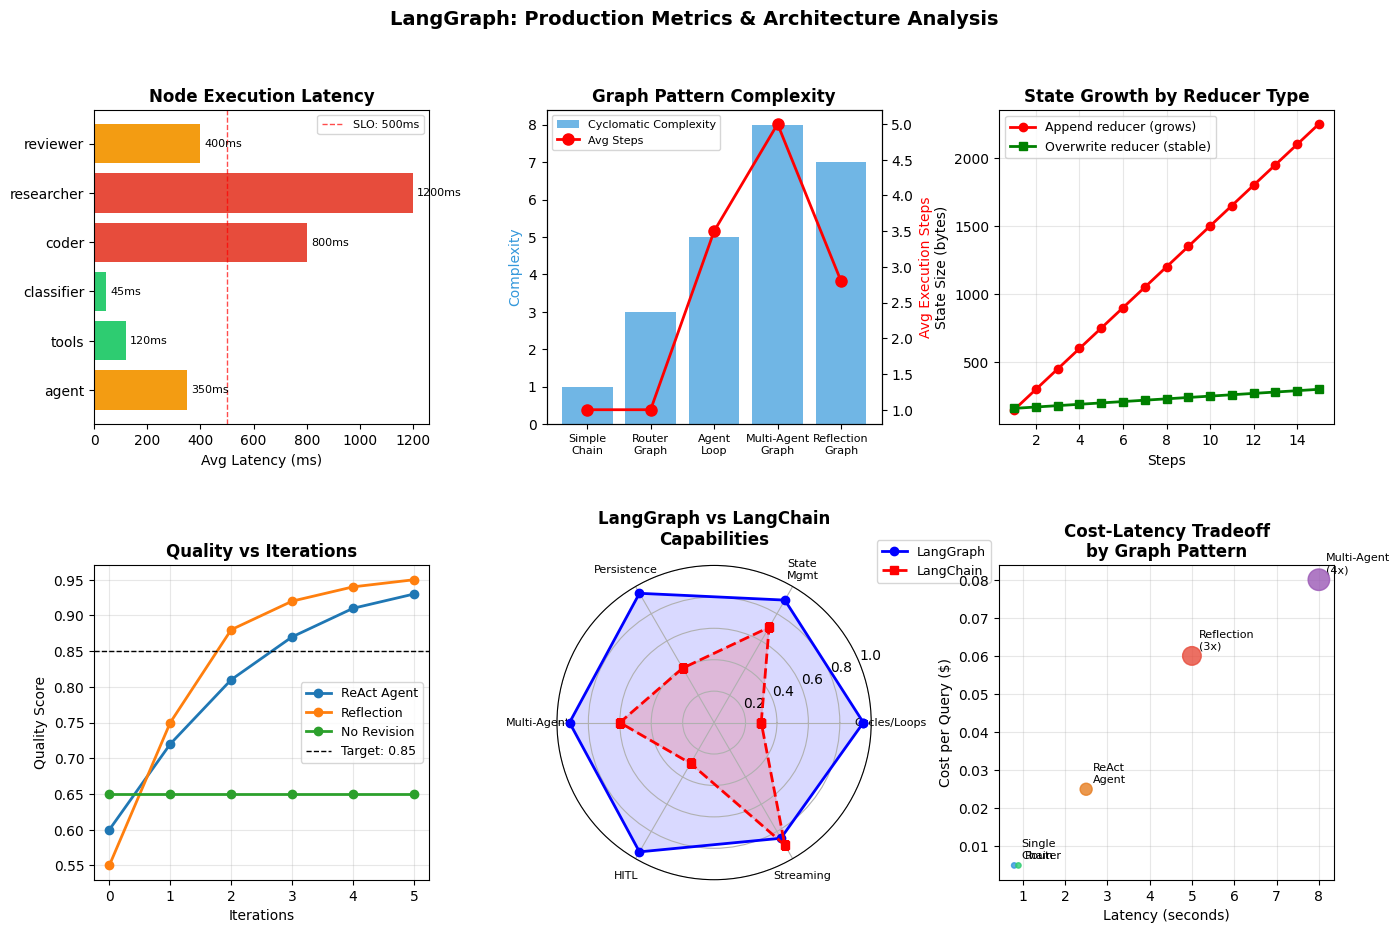


LangGraph End-to-End Notebook Complete
   StateGraph core primitives (State, Nodes, Edges)
   StateSchema with reducers (add_messages, overwrite)
   Conditional routing and multi-branch graphs
   Agent loop with cycles (ReAct pattern)
   SQLite checkpointing and state persistence
   Human-in-the-loop with interrupt/resume
   Multi-agent coordination (Supervisor pattern)
   Reflection/self-critique cycles
   Production metrics: latency, cost, quality
   LangGraph vs LangChain capability comparison


In [ ]:
# Cell 9: Full Production Dashboard + Summary
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Node execution time heatmap
ax1 = fig.add_subplot(gs[0, 0])
nodes = ['agent', 'tools', 'classifier', 'coder', 'researcher', 'reviewer']
avg_ms = [350, 120, 45, 800, 1200, 400]
colors = ['firebrick' if t > 500 else 'goldenrod' if t > 200 else 'seagreen' for t in avg_ms]
bars = ax1.barh(nodes, avg_ms, color=colors)
for bar, ms in zip(bars, avg_ms):
    ax1.text(ms+15, bar.get_y()+bar.get_height()/2, f'{ms}ms', va='center', fontsize=8)
ax1.set_xlabel('Avg Latency (ms)'); ax1.set_title('Node Execution Latency', fontweight='bold')
ax1.axvline(x=500, color='red', linestyle='--', linewidth=1, alpha=0.7, label='SLO: 500ms')
ax1.legend(fontsize=8)

# 2. Graph complexity metrics
ax2 = fig.add_subplot(gs[0, 1])
patterns = ['Simple\nChain', 'Router\nGraph', 'Agent\nLoop', 'Multi-Agent\nGraph', 'Reflection\nGraph']
complexity = [1, 3, 5, 8, 7]  # cyclomatic complexity
avg_steps = [1, 1, 3.5, 5, 2.8]
ax2_twin = ax2.twinx()
x = range(len(patterns))
ax2.bar(x, complexity, alpha=0.7, color='royalblue', label='Cyclomatic Complexity')
ax2_twin.plot(x, avg_steps, 'ro-', linewidth=2, markersize=8, label='Avg Steps')
ax2.set_xticks(x); ax2.set_xticklabels(patterns, fontsize=8)
ax2.set_ylabel('Complexity', color='royalblue')
ax2_twin.set_ylabel('Avg Execution Steps', color='red')
ax2.set_title('Graph Pattern Complexity', fontweight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

# 3. State size growth
ax3 = fig.add_subplot(gs[0, 2])
steps_range = list(range(1, 16))
append_state = [s * 150 for s in steps_range]  # bytes
checkpoint_state = [150 + s * 10 for s in steps_range]
ax3.plot(steps_range, append_state, 'r-o', label='Append reducer (grows)', linewidth=2)
ax3.plot(steps_range, checkpoint_state, 'g-s', label='Overwrite reducer (stable)', linewidth=2)
ax3.set_xlabel('Steps'); ax3.set_ylabel('State Size (bytes)')
ax3.set_title('State Growth by Reducer Type', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

# 4. Reflection quality improvement
ax4 = fig.add_subplot(gs[1, 0])
iters = [0, 1, 2, 3, 4, 5]
approaches = {'ReAct Agent': [0.60, 0.72, 0.81, 0.87, 0.91, 0.93],
               'Reflection': [0.55, 0.75, 0.88, 0.92, 0.94, 0.95],
               'No Revision': [0.65, 0.65, 0.65, 0.65, 0.65, 0.65]}
for name, scores in approaches.items():
    ax4.plot(iters, scores, '-o', linewidth=2, markersize=6, label=name)
ax4.axhline(y=0.85, color='black', linestyle='--', linewidth=1, label='Target: 0.85')
ax4.set_xlabel('Iterations'); ax4.set_ylabel('Quality Score')
ax4.set_title('Quality vs Iterations', fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

# 5. LangGraph vs LangChain
ax5 = fig.add_subplot(gs[1, 1], polar=True)
cats = ['Cycles/Loops', 'State\nMgmt', 'Persistence', 'Multi-Agent', 'HITL', 'Streaming']
N = len(cats)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]
lg_scores = [0.95, 0.90, 0.95, 0.92, 0.95, 0.85]
lc_scores = [0.30, 0.70, 0.40, 0.60, 0.30, 0.90]
lg_scores += lg_scores[:1]
lc_scores += lc_scores[:1]
ax5.plot(angles, lg_scores, 'b-o', linewidth=2, label='LangGraph')
ax5.fill(angles, lg_scores, alpha=0.15, color='blue')
ax5.plot(angles, lc_scores, 'r--s', linewidth=2, label='LangChain')
ax5.fill(angles, lc_scores, alpha=0.15, color='red')
ax5.set_xticks(angles[:-1]); ax5.set_xticklabels(cats, fontsize=8)
ax5.set_ylim(0, 1); ax5.set_title('LangGraph vs LangChain\nCapabilities', fontweight='bold', pad=15)
ax5.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)

# 6. Cost per graph pattern
ax6 = fig.add_subplot(gs[1, 2])
patterns2 = ['Single\nChain', 'Router', 'ReAct\nAgent', 'Reflection\n(3x)', 'Multi-Agent\n(4x)']
cost_per_query = [0.005, 0.005, 0.025, 0.060, 0.080]
latency_sec = [0.8, 0.9, 2.5, 5.0, 8.0]
scatter = ax6.scatter(latency_sec, cost_per_query, s=[c*3000 for c in cost_per_query],
                       c=['royalblue','seagreen','darkorange','firebrick','mediumpurple'], alpha=0.8, zorder=5)
for i, pat in enumerate(patterns2):
    ax6.annotate(pat, (latency_sec[i], cost_per_query[i]),
                  textcoords='offset points', xytext=(5, 5), fontsize=8)
ax6.set_xlabel('Latency (seconds)', fontsize=10)
ax6.set_ylabel('Cost per Query ($)', fontsize=10)
ax6.set_title('Cost-Latency Tradeoff\nby Graph Pattern', fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.suptitle('LangGraph: Production Metrics & Architecture Analysis', fontsize=14, fontweight='bold')
plt.savefig('langgraph_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('LangGraph End-to-End Notebook Complete')
print('='*60)
topics = [
    'StateGraph core primitives (State, Nodes, Edges)',
    'StateSchema with reducers (add_messages, overwrite)',
    'Conditional routing and multi-branch graphs',
    'Agent loop with cycles (ReAct pattern)',
    'SQLite checkpointing and state persistence',
    'Human-in-the-loop with interrupt/resume',
    'Multi-agent coordination (Supervisor pattern)',
    'Reflection/self-critique cycles',
    'Production metrics: latency, cost, quality',
    'LangGraph vs LangChain capability comparison',
]
for topic in topics:
    print(f'  - {topic}')

## Production Patterns & Interview Guide

### When to use LangGraph vs LangChain?

| Scenario | Use |
|----------|-----|
| Linear prompt → LLM → response | LangChain LCEL |
| RAG pipeline | LangChain |
| Simple chain with memory | LangChain |
| Agent that loops until done | **LangGraph** |
| Requires human approval step | **LangGraph** |
| Multi-agent coordination | **LangGraph** |
| Long-running workflows with resume | **LangGraph** |
| Self-critique/reflection loops | **LangGraph** |

### Key Interview Questions

1. **What is the difference between a Node and an Edge in LangGraph?**
   - Node: processing function `(state) -> partial_state_update`
   - Edge: connection/routing between nodes (normal or conditional)

2. **How does state management work?**
   - State is a TypedDict; each field has a reducer function
   - Nodes return partial updates; the graph merges them using reducers
   - `add_messages` appends; default is overwrite

3. **How do you prevent infinite loops?**
   - Always have a termination condition in the router function
   - Set `recursion_limit` in graph config (default: 25)
   - Track iteration count in state and check in router

4. **How does checkpointing enable HITL?**
   - `interrupt_before`/`interrupt_after` pauses execution after a node
   - State is saved to checkpointer (Redis, SQLite, PostgreSQL)
   - `graph.update_state()` injects human feedback
   - `graph.invoke(None, config)` resumes from checkpoint

5. **Explain the Supervisor multi-agent pattern**
   - Supervisor LLM decides which agent to call next
   - Each agent returns control to supervisor after completion
   - Supervisor says `FINISH` when task is complete
   - State accumulates results from all agents

### State Reducer Complexity

For messages field with `add_messages` reducer:

$$\text{memory}(n) = O(n) \text{ where } n = \text{total messages}$$

Mitigation: trim messages or use summary:

$$\text{messages\_to\_keep} = \text{messages}[-k:]$$

### Production Checklist

- [ ] Set `recursion_limit` to prevent runaway agents
- [ ] Use `AsyncCompiledGraph` for production throughput
- [ ] Configure PostgreSQL checkpointer (not SQLite) for scale
- [ ] Add LangSmith tracing for debugging
- [ ] Implement timeout per node execution
- [ ] Validate state schema at graph compile time
- [ ] Test all conditional edge paths
- [ ] Monitor token usage per thread
- [ ] Implement retry logic for LLM failures
- [ ] Use streaming for real-time UI updates